In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt



image = cv2.imread('sar_3.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

Tsk 1

Longest segment length: 235.3 px
Endpoints: (15, 179) -> (223, 69)


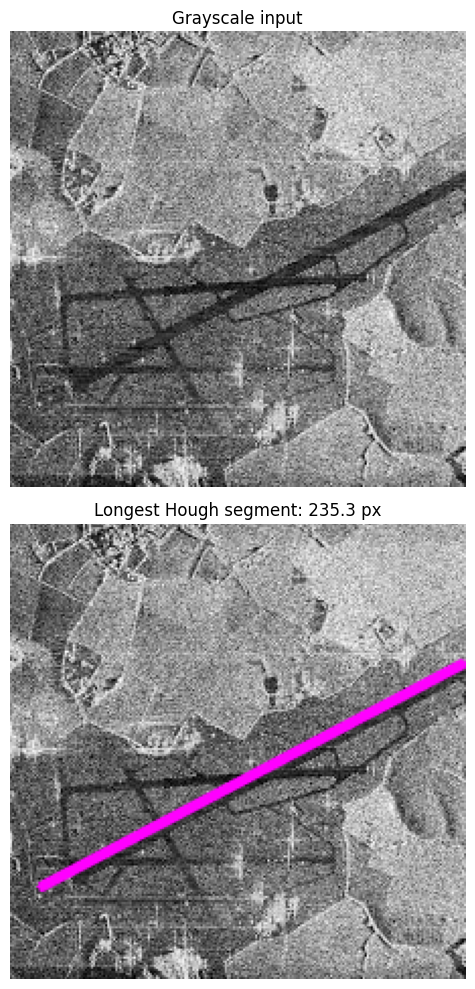

In [3]:
def to_rgb(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

def longest_hough_segment(gray_img):
    smoothed = cv2.medianBlur(gray_img, 5)
    edges = cv2.Canny(smoothed, 50, 150, apertureSize=3)

    hough_lines = cv2.HoughLinesP(
        edges,
        1,
        np.pi / 180,
        threshold=80,
        minLineLength=100,
        maxLineGap=20
    )

    if hough_lines is None:
        return None, 0.0

    segments = hough_lines.reshape(-1, 4)
    dx = segments[:, 2] - segments[:, 0]
    dy = segments[:, 3] - segments[:, 1]
    lengths = np.hypot(dx, dy)

    best_index = int(np.argmax(lengths))
    x1, y1, x2, y2 = segments[best_index]

    return (x1, y1, x2, y2), float(lengths[best_index])


best_segment, best_length = longest_hough_segment(gray)

segment_visual = image.copy()

if best_segment is not None:
    x1, y1, x2, y2 = best_segment
    cv2.line(
        segment_visual,
        (x1, y1),
        (x2, y2),
        (255, 0, 255),
        3,
        cv2.LINE_AA
    )

    print(f"Longest segment length: {best_length:.1f} px")
    print(f"Endpoints: ({x1}, {y1}) -> ({x2}, {y2})")
else:
    print("No Hough segments found.")

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Grayscale input')
axes[0].axis('off')

axes[1].imshow(to_rgb(segment_visual))
axes[1].set_title(f'Longest Hough segment: {best_length:.1f} px')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Task 2

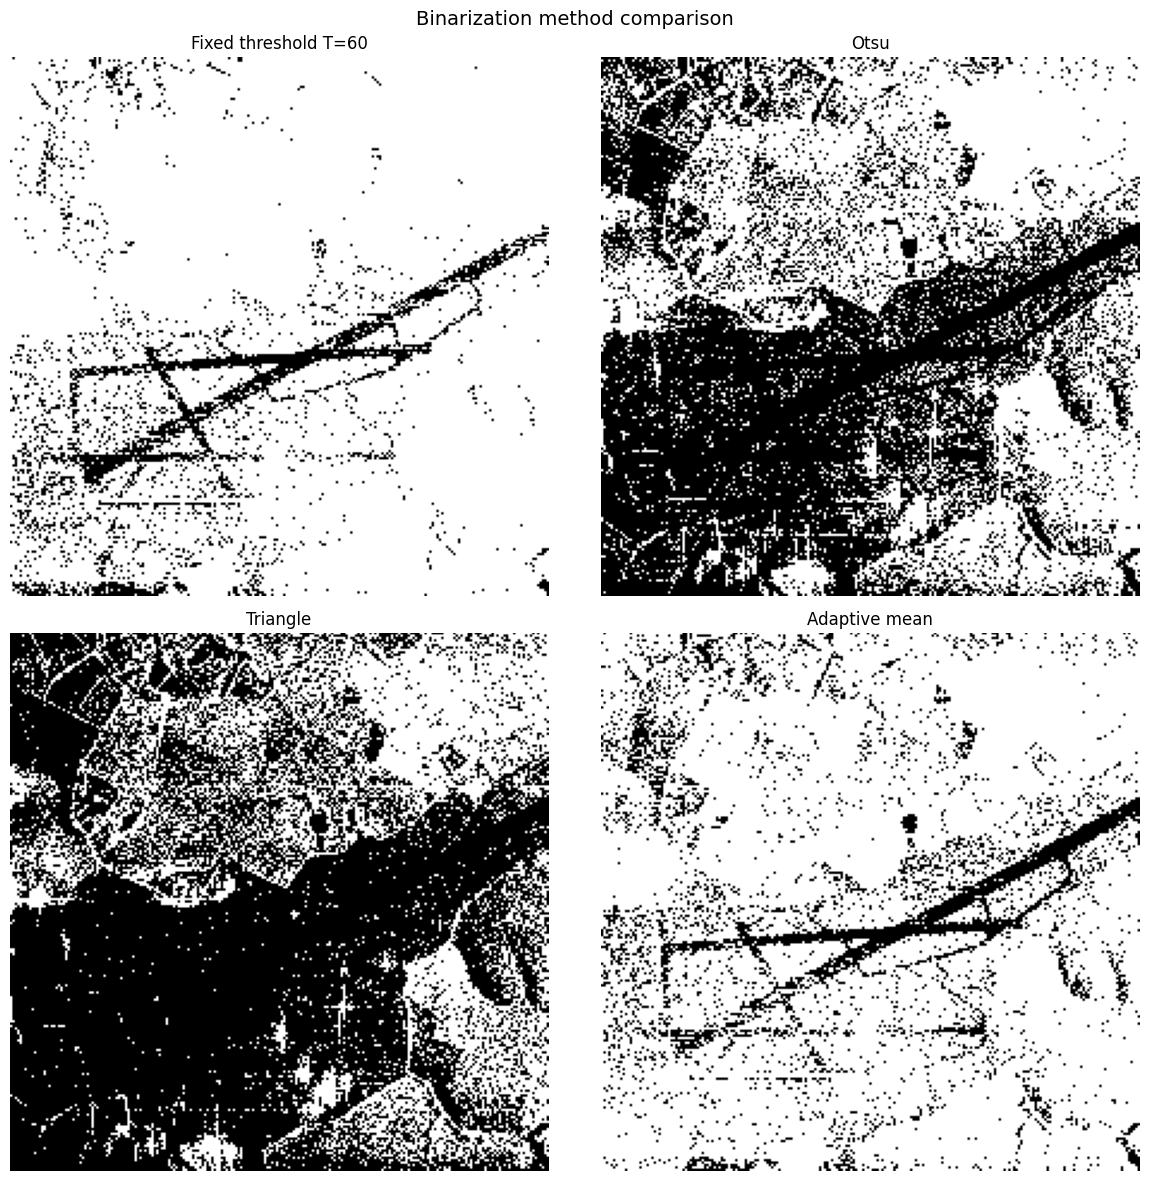

White pixel ratio:
  Fixed threshold T=60: 0.911
  Otsu: 0.514
  Triangle: 0.335
  Adaptive mean: 0.864


In [4]:
def build_binarization_set(gray_img):
    _, fixed = cv2.threshold(
        gray_img,
        60,
        255,
        cv2.THRESH_BINARY
    )

    _, otsu = cv2.threshold(
        gray_img,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    _, triangle = cv2.threshold(
        gray_img,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_TRIANGLE
    )

    adaptive_mean = cv2.adaptiveThreshold(
        gray_img,
        255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY,
        101,
        45
    )

    return {
        'Fixed threshold T=60': fixed,
        'Otsu': otsu,
        'Triangle': triangle,
        'Adaptive mean': adaptive_mean
    }


binary_set = build_binarization_set(gray)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for ax, (method_name, binary_img) in zip(axes.ravel(), binary_set.items()):
    ax.imshow(binary_img, cmap='gray')
    ax.set_title(method_name)
    ax.axis('off')

plt.suptitle('Binarization method comparison', fontsize=14)
plt.tight_layout()
plt.show()

print("White pixel ratio:")

for method_name, binary_img in binary_set.items():
    white_ratio = np.count_nonzero(binary_img) / binary_img.size
    print(f"  {method_name}: {white_ratio:.3f}")

Road:

Road-lane contours kept: 2


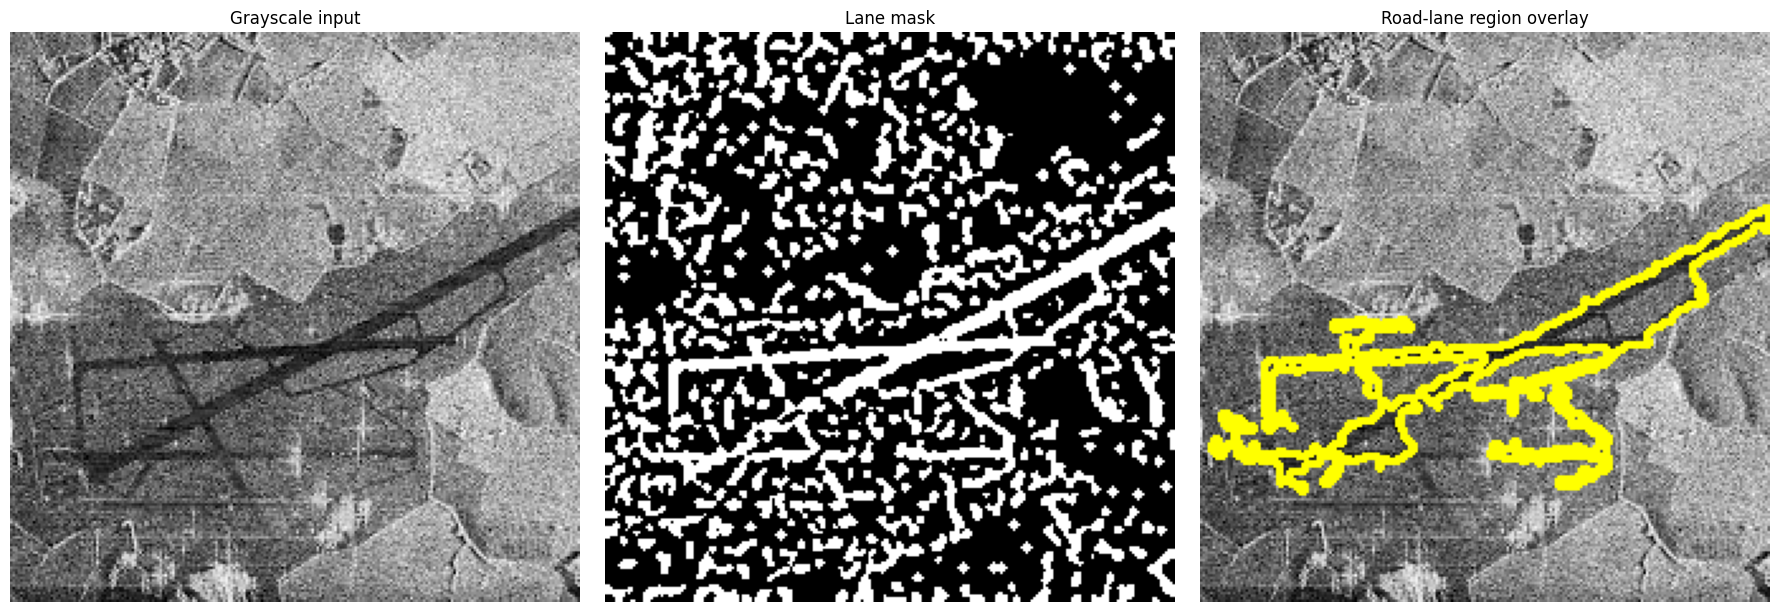

In [5]:
base_binary = binary_set['Adaptive mean']

soft_binary = cv2.GaussianBlur(
    base_binary,
    (7, 7),
    0
)

lane_mask = cv2.adaptiveThreshold(
    soft_binary,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    11,
    2
)

contours, _ = cv2.findContours(
    lane_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

lane_visual = image.copy()
kept_regions = 0

for contour in contours:
    if cv2.contourArea(contour) > 500:
        cv2.drawContours(
            lane_visual,
            [contour],
            -1,
            (0, 255, 255),
            2
        )
        kept_regions += 1

print(f"Road-lane contours kept: {kept_regions}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Grayscale input')
axes[0].axis('off')

axes[1].imshow(lane_mask, cmap='gray')
axes[1].set_title('Lane mask')
axes[1].axis('off')

axes[2].imshow(to_rgb(lane_visual))
axes[2].set_title('Road-lane region overlay')
axes[2].axis('off')

plt.tight_layout()
plt.show()